In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from LUloader import LUloader
from model import GDAmodel
import objs

Func_types = ['Restrict', 'U', 'C', 'T']
Func_cmap = ['white', 'lightgray', 'springgreen', 'forestgreen']

thC = 80 # threshod of conversion limit
objX = 4
outName = f'objpre120_{objs.n_obj[0][objX]}'

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
%matplotlib inline
CL = LUloader(LUs=Func_types, asProb=True, LUType='V', LUname=f'luX', LUcol='lu', driver='feather', cmap=Func_cmap, path='CL')
# CL.plot_LU()

w = pd.read_csv('CL/Ws.csv').set_index('PAC')
wx = CL.raw.copy()
wx['grid_code'] = wx['grid_code'].astype(int)
p = pd.DataFrame({i: wx.grid_code == i for i in w.index}).astype(int)

wx['food'] = wx['priority2'] * wx['food'] / 10 * wx['grid_code'].apply(lambda x: w['FOOD'][x])
wx['tree'] = wx['priority2'] * wx['tree'] / 10 * wx['grid_code'].apply(lambda x: w['NEP'][x])
wx['biod'] = wx['priority2'] * wx['tree'] / 10 * wx['grid_code'].apply(lambda x: w['BIO'][x])

wx['foodvaluec'] = wx['priority2'] * wx['food'] / 10 * wx['grid_code'].apply(lambda x: w['FOODVALUEC'][x])
wx['foodvalued'] = wx['priority2'] * wx['food'] / 10 * wx['grid_code'].apply(lambda x: w['FOODVALUED'][x])

wx['treevaluec'] = wx['priority2'] * wx['tree'] / 10 * wx['grid_code'].apply(lambda x: w['TREEVALUEC'][x])
wx['treevalued'] = wx['priority2'] * wx['tree'] / 10 * wx['grid_code'].apply(lambda x: w['TREEVALUED'][x])


wx = wx[['pointid', 'food', 'tree', 'biod', 'foodvaluec', 'foodvalued', 'treevaluec', 'treevalued', 'priority2']]

maskR = np.ones_like(CL.var.LU)
# maskR[:, 1] = wx['food'] > 0
# maskR[:, 2] = wx['tree'] > 0
# maskR[:, 3] = wx['biod'] > 0
# maskR[:, 4] = wx['foodvaluec'] > 0
# maskR[:, 5] = wx['foodvalued'] > 0
# maskR[:, 6] = wx['treevaluec'] > 0
# maskR[:, 7] = wx['treevalued'] > 0


CCM = np.loadtxt('CL/CCM.csv', delimiter=',')
CCM = 1 - CCM / CCM.max()

M = {'LU': CL}
con = dict(
    food=wx['food'].to_numpy(), tree=wx['tree'].to_numpy(), biod=wx['biod'].to_numpy(),
    foodvaluec=wx['foodvaluec'].to_numpy(), foodvalued=wx['foodvalued'].to_numpy(),
    treevaluec=wx['treevaluec'].to_numpy(), treevalued=wx['treevalued'].to_numpy(),
    CCM=CCM, oLU=CL.var.LU.to_numpy().copy()
)

Loading vector landuse: luX, LUCol: lu, Driver: feather/utf-8
Loaded vector: CL\luX[feather/utf-8: 357714]


Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5

initial...
food -44403732.0 -2015.7434
nep -13977713.0 -634.5296
bio -21495612.0 -975.8107
ecoc -44594120.0 -2041.7499
ecod -423208420.0 -26260.504
epoch: None, loss: 2.0
food: -2015.7434056282555, 0.9999999987226204
nep: -634.5295958576988, 0.9999999902398842
bio: -975.8107195361163, 0.9999999892967436
ecoc: -2041.7498532221716, 0.9999999878988528
ecod: -26260.503618133986, 0.999999989028542
Cov: 357679.6875, 0.9999834875932853


g:\OneDrive - The University Of Hong Kong\spatial_optimization\CLand\COMC-main\code\LUloader.py:233: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


{'epoch': None,
 'loss': 2.0,
 'loss1': array([ -2015.7434,   -634.5296,   -975.8107,  -2041.7499, -26260.504 ],
       dtype=float32),
 'loss2': array([357685.6], dtype=float32),
 'obs1': array([ -2015.74340563,   -634.52959586,   -975.81071954,  -2041.74985322,
        -26260.50361813]),
 'obs2': array([357679.6875]),
 'obs1R': array([1.        , 0.99999999, 0.99999999, 0.99999999, 0.99999999]),
 'obs2R': array([0.99998349]),
 'food': -2015.7434056282555,
 'foodnorm': 0.9999999987226204,
 'nep': -634.5295958576988,
 'nepnorm': 0.9999999902398842,
 'bio': -975.8107195361163,
 'bionorm': 0.9999999892967436,
 'ecoc': -2041.7498532221716,
 'ecocnorm': 0.9999999878988528,
 'ecod': -26260.503618133986,
 'ecodnorm': 0.999999989028542,
 'Cov': 357679.6875,
 'Covnorm': 0.9999834875932853}

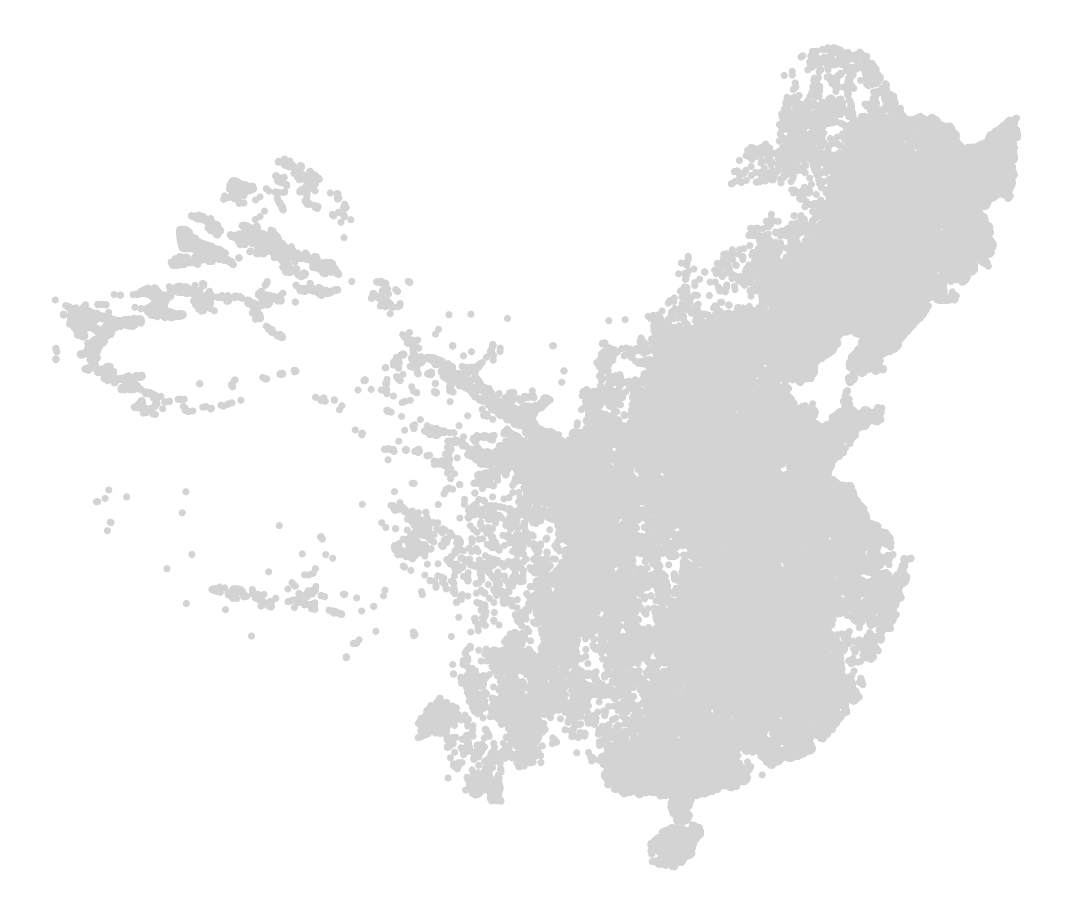

In [3]:
Model = GDAmodel(M, con, maskR, objs, thC=thC/100., GPU=1, path='CL')
# print(Model.LU.shape)

Model.init_train(500, lr=0.1)       # no init file: run init_train
Model.save_inp()                    # save init file
# Model.init_train_load('inp', 0.1)  # skip init_train and load init file
Model.log()

In [4]:
# from model import GDAmodel
# import objs

# # thC = 0.98  # threshod of conversion limit
# Model = GDAmodel(M, con, maskR, objs, thC=thC, GPU=1, path='CL')
# Model.init_train_load('inp', 0.1)  # skip init_train and load init file


g:\OneDrive - The University Of Hong Kong\spatial_optimization\CLand\COMC-main\code\LUloader.py:233: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


epoch: 85, loss: 0.62711775
food: -25130312.614720747, 12467.01961789989
nep: -7908175.07564579, 12463.05144801251
bio: -14744997.574060204, 15110.509775143926
ecoc: -26852765.657028716, 13151.838992275161
ecod: -368144908.71923256, 14018.958281741656
Cov: 68986.21875, 0.19286831775007712
epoch: 85, loss: 0.62711775
food: -25130312.614720747, 12467.01961789989
nep: -7908175.07564579, 12463.05144801251
bio: -14744997.574060204, 15110.509775143926
ecoc: -26852765.657028716, 13151.838992275161
ecod: -368144908.71923256, 14018.958281741656
Cov: 68986.21875, 0.19286831775007712


g:\OneDrive - The University Of Hong Kong\spatial_optimization\CLand\COMC-main\code\LUloader.py:233: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


{'epoch': 85,
 'loss': 0.62711775,
 'loss1': array([-2.5130314e+07, -7.9081750e+06, -1.4744997e+07, -2.6852766e+07,
        -3.6814490e+08], dtype=float32),
 'loss2': array([68986.22], dtype=float32),
 'obs1': array([-2.51303126e+07, -7.90817508e+06, -1.47449976e+07, -2.68527657e+07,
        -3.68144909e+08]),
 'obs2': array([68986.21875]),
 'obs1R': array([12467.0196179 , 12463.05144801, 15110.50977514, 13151.83899228,
        14018.95828174]),
 'obs2R': array([0.19286832]),
 'food': -25130312.614720747,
 'foodnorm': 12467.01961789989,
 'nep': -7908175.07564579,
 'nepnorm': 12463.05144801251,
 'bio': -14744997.574060204,
 'bionorm': 15110.509775143926,
 'ecoc': -26852765.657028716,
 'ecocnorm': 13151.838992275161,
 'ecod': -368144908.71923256,
 'ecodnorm': 14018.958281741656,
 'Cov': 68986.21875,
 'Covnorm': 0.19286831775007712}

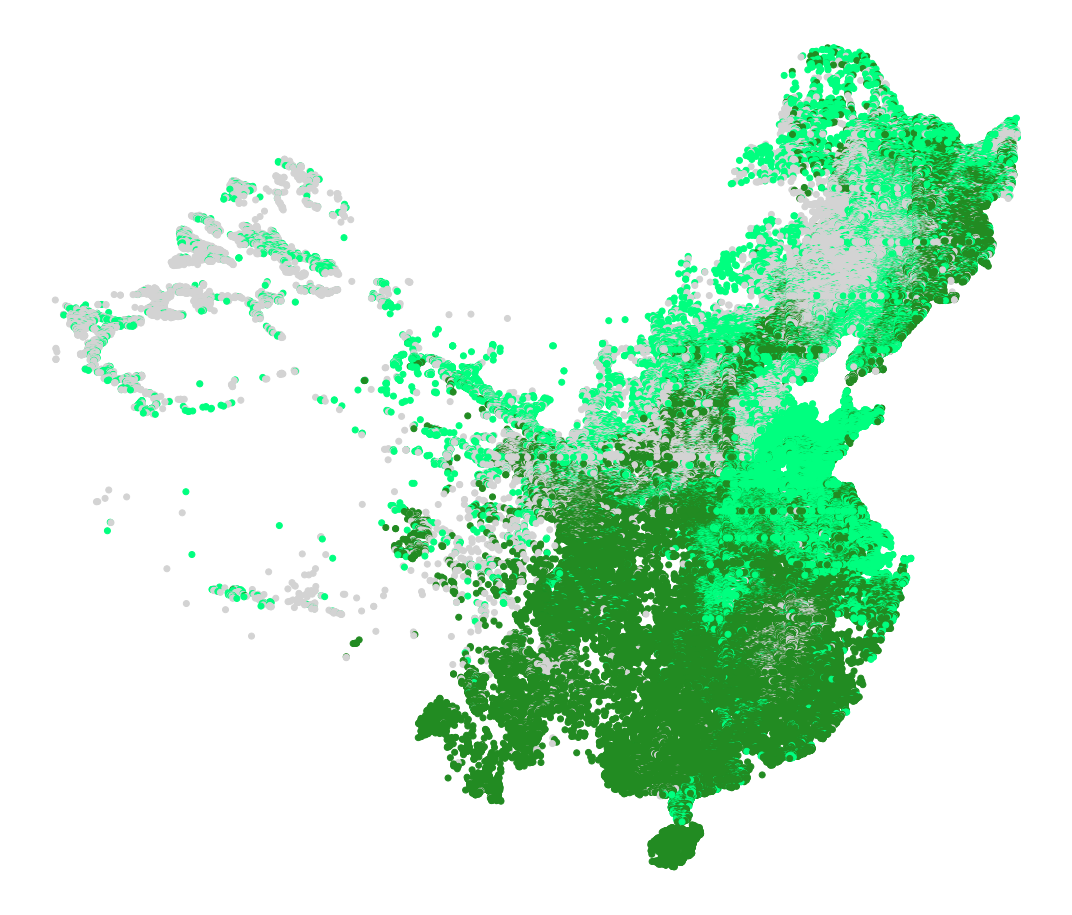

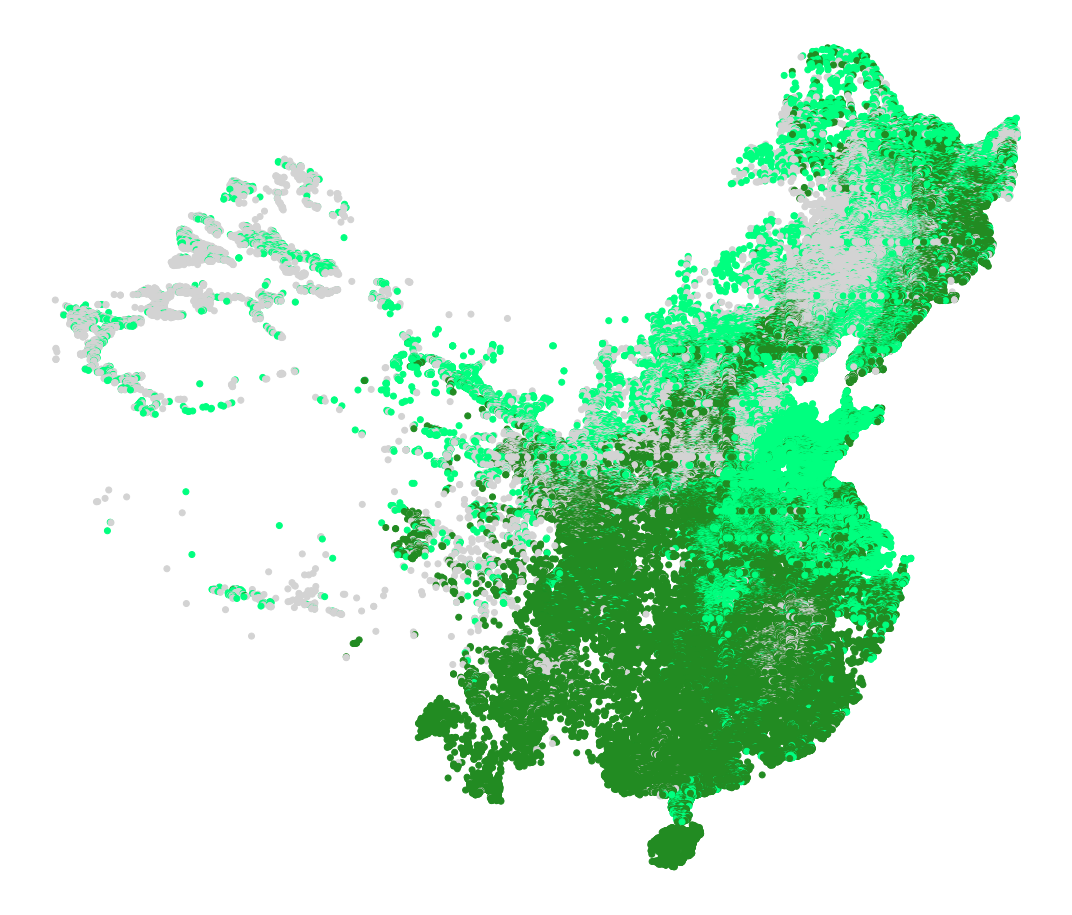

In [5]:

pre = [1] * len(objs.n_obj[0])
pre[objX] = 1.2
Model.perference(pre)
Model.train(n_iter=1000, thStop=1, nprint=None)  # set nprint=None to close printing and ploting
# img will be saved in plot/LU

Model.log()
# Model.plot_opt()

In [6]:
# lu_matrix = Model.get_opt()['LU']

# # 将矩阵转换为 DataFrame
# df = pd.DataFrame(lu_matrix, columns=['Column1', 'Column2', 'Column3'])
# excel_file_path = 'duo4output.xlsx'
# with pd.ExcelWriter(excel_file_path) as writer:
#     df.to_excel(writer, index=False, sheet_name='Sheet1')

In [7]:
LUmax = pd.Series(Model.get_opt()['LU'].argmax(axis=1), index=CL.raw.pointid, name='LU')
gdf = gpd.read_file('data2/dixiao-xiugai-xiaochu-HOUXUAN7501-shai_with_elderly-qutaihong', encoding='utf8').set_index('PatchUID')
gdf['LU'] = LUmax
gdf = gdf.reset_index()
gdf[['PatchUID', 'LU', 'geometry']].fillna(0).to_file(f'sensitivity/{outName}')